<a href="https://colab.research.google.com/github/dhanusharer/DL-practise/blob/main/transformers01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***potato leveas classification usin VGG16***

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noulam/tomato")

print("Path to dataset files:", path)

100%|██████████| 743M/743M [00:11<00:00, 65.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/noulam/tomato/versions/1


In [2]:
!pip install tensorflow-gpu

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
import tensorflow as tf

In [4]:
tf.__version__

'2.19.0'

In [5]:
from keras.layers import Input,Dense,Lambda,Flatten
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from keras.models import Sequential
import numpy as np
import glob as glob

In [6]:
IMAGE_SIZE=[224,224]


In [7]:
import os

# Assuming 'path' variable is available from previous execution
train_path = os.path.join(path, 'train')
valid_path = os.path.join(path, 'valid')

# Verify paths exist
print(f"Train path: {train_path}, Exists: {os.path.exists(train_path)}")
print(f"Validation path: {valid_path}, Exists: {os.path.exists(valid_path)}")

Train path: /root/.cache/kagglehub/datasets/noulam/tomato/versions/1/train, Exists: False
Validation path: /root/.cache/kagglehub/datasets/noulam/tomato/versions/1/valid, Exists: False


In [14]:
import os

# The original 'path' variable is '/root/.cache/kagglehub/datasets/noulam/tomato/versions/1'
# The previous attempt to find 'train' and 'valid' paths was incorrect.
# Let's inspect the contents of the base path to find the correct subdirectory.
# print(f"Contents of {path}: {os.listdir(path)}") # Already executed and provided output

# Based on the inspection, we'll redefine train_path and valid_path accordingly.
# The output was: Contents of /root/.cache/kagglehub/datasets/noulam/tomato/versions/1: ['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)']
# We will use 'New Plant Diseases Dataset(Augmented)' as the base for train and valid paths.

new_base_path = os.path.join(path, 'New Plant Diseases Dataset(Augmented)')

train_path = os.path.join(new_base_path, 'train')
valid_path = os.path.join(new_base_path, 'valid')

# Verify new paths exist before proceeding
print(f"Corrected Train path: {train_path}, Exists: {os.path.exists(train_path)}")
print(f"Corrected Validation path: {valid_path}, Exists: {os.path.exists(valid_path)}")

batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size=IMAGE_SIZE,
                                                 batch_size=batch_size,
                                                 class_mode='categorical')

validation_set = test_datagen.flow_from_directory(valid_path,
                                                   target_size=IMAGE_SIZE,
                                                   batch_size=batch_size,
                                                   class_mode='categorical')

Corrected Train path: /root/.cache/kagglehub/datasets/noulam/tomato/versions/1/New Plant Diseases Dataset(Augmented)/train, Exists: True
Corrected Validation path: /root/.cache/kagglehub/datasets/noulam/tomato/versions/1/New Plant Diseases Dataset(Augmented)/valid, Exists: True
Found 18345 images belonging to 10 classes.
Found 4585 images belonging to 10 classes.


In [12]:
IMAGE_SIZE=[224,224]
inception = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:

for layer in inception.layers:
    layer.trainable = False

In [15]:
print("Classes found in training set:")
print(training_set.class_indices)

print("\nClasses found in validation set:")
print(validation_set.class_indices)

Classes found in training set:
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}

Classes found in validation set:
{'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [16]:
x = Flatten()(inception.output)

In [18]:
prediction = Dense(len(training_set.class_indices), activation='softmax')(x)

# create a model object
model = Model(inputs=inception.input, outputs=prediction)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,965,578 (57.09 MB)

 Trainable params: 250,890 (980.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:

model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [23]:
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 18345 images belonging to 10 classes.


In [27]:
# Using the validation set as the test set
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 4585 images belonging to 10 classes.


In [29]:
# fit the model
# Run the cell. It will take some time to execute
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 297s 489ms/step - accuracy: 0.6628 - loss: 1.0772 - val_accuracy: 0.8312 - val_loss: 0.5232
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 272s 474ms/step - accuracy: 0.8579 - loss: 0.4313 - val_accuracy: 0.8153 - val_loss: 0.6032
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 271s 471ms/step - accuracy: 0.8790 - loss: 0.3596 - val_accuracy: 0.8523 - val_loss: 0.4139
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 273s 475ms/step - accuracy: 0.8990 - loss: 0.2877 - val_accuracy: 0.8763 - val_loss: 0.3991
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 270s 471ms/step - accuracy: 0.9146 - loss: 0.2552 - val_accuracy: 0.9134 - val_loss: 0.2731
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 272s 473ms/step - accuracy: 0.9117 - loss: 0.2590 - val_accuracy: 0.8652 - val_loss: 0.4774
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 271s 472ms/step - accuracy: 0.9173 - loss: 0.2400 - val_accuracy: 0.9156 - val_loss: 0.2677
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 271s 472ms/step - accuracy: 0.9267 -

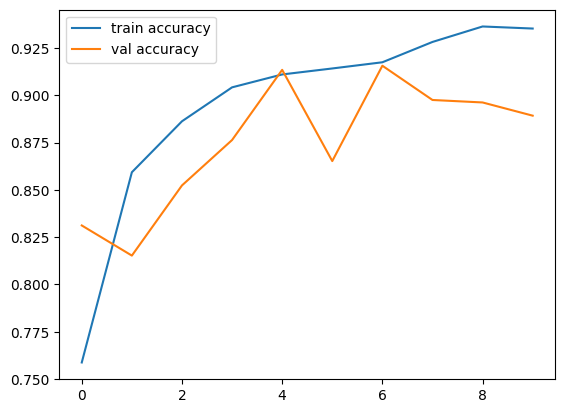

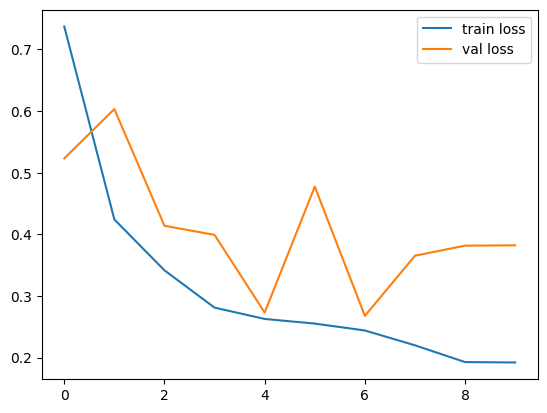

In [30]:
import matplotlib.pyplot as plt

# Plot the accuracy
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

# Plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()

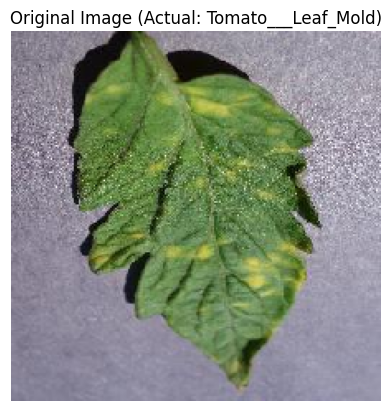

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Predicted Class: Tomato___Tomato_mosaic_virus
Confidence: 100.00%
Actual Class: Tomato___Leaf_Mold


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Get the class names from the training set
class_names = list(training_set.class_indices.keys())

# Choose a class to pick a sample from (e.g., the first class)
# You can change this index to pick from a different class
random_class_idx = np.random.randint(0, len(class_names))
selected_class_name = class_names[random_class_idx]

# Path to the selected class folder within the validation set
selected_class_path = os.path.join(valid_path, selected_class_name)

# List all image files in that directory
image_files = [f for f in os.listdir(selected_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print(f"No image files found in {selected_class_path}")
else:
    # Pick a random image from that class
    random_image_file = np.random.choice(image_files)
    img_path = os.path.join(selected_class_path, random_image_file)

    # Load the image
    img = image.load_img(img_path, target_size=IMAGE_SIZE)
    plt.imshow(img)
    plt.title(f"Original Image (Actual: {selected_class_name})")
    plt.axis('off')
    plt.show()

    # Preprocess the image
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = preprocess_input(img_array) # Use VGG16's preprocess_input

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted Class: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Actual Class: {selected_class_name}")

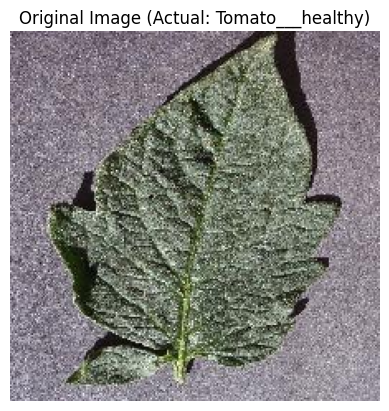

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicted Class: Tomato___healthy
Confidence: 100.00%
Actual Class: Tomato___healthy


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Get the class names from the training set
class_names = list(training_set.class_indices.keys())

# Choose a class to pick a sample from (e.g., the first class)
# You can change this index to pick from a different class
random_class_idx = np.random.randint(0, len(class_names))
selected_class_name = class_names[random_class_idx]

# Path to the selected class folder within the validation set
selected_class_path = os.path.join(valid_path, selected_class_name)

# List all image files in that directory
image_files = [f for f in os.listdir(selected_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print(f"No image files found in {selected_class_path}")
else:
    # Pick a random image from that class
    random_image_file = np.random.choice(image_files)
    img_path = os.path.join(selected_class_path, random_image_file)

    # Load the image
    img = image.load_img(img_path, target_size=IMAGE_SIZE)
    plt.imshow(img)
    plt.title(f"Original Image (Actual: {selected_class_name})")
    plt.axis('off')
    plt.show()

    # Preprocess the image
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = preprocess_input(img_array) # Use VGG16's preprocess_input

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\nPredicted Class: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Actual Class: {selected_class_name}")

In [31]:
print(f"Final training accuracy: {r.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {r.history['val_accuracy'][-1]:.4f}")

Final training accuracy: 0.9352
Final validation accuracy: 0.8892
